## CMPINF 2100 Week 11

### Working with LINEAR MODELS with INTERACTION features

Let's read in the data we created in the PREVIOUS ADDITIVE features demonstration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
import statsmodels.formula.api as smf

## Read Data

In [3]:
df = pd.read_csv('linear_additive_example.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      35 non-null     float64
 1   x2      35 non-null     float64
 2   trend   35 non-null     float64
 3   y       35 non-null     float64
dtypes: float64(4)
memory usage: 1.2 KB


In [7]:
df.head()

,x1,x2,trend,y
0,1.024252,-0.650623,1.617167,1.567586
1,-1.733671,0.993904,-3.431878,-3.510933
2,-0.089294,0.251805,-0.373762,-0.352691
3,-1.093748,1.356543,-2.111500,-2.218024
4,0.320995,-0.145121,0.346917,0.328151


## Fit linear model with INTERACTIONS

The formula interface has several STRANGE and WEIRD...YET...quite useful syntax artifacts when working with INTERACTIONS

In [8]:
fit_a = smf.ols(formula='y ~ x1 + x2 + x1 * x2', data=df).fit() 

In [9]:
fit_a.params

Intercept   -0.255648
x1           1.932954
x2           0.193624
x1:x2        0.003126
dtype: float64

Let's use the FORMULA INTERACTIONS actual SYNTAX for the MULTIPLICATION or INTERACTION FEATURE

In [10]:
fit_b = smf.ols(formula='y ~ x1 + x2 + x1:x2', data=df).fit()

In [11]:
fit_b.params

Intercept   -0.255648
x1           1.932954
x2           0.193624
x1:x2        0.003126
dtype: float64

In [12]:
fit_b.bse

Intercept    0.009332
x1           0.010605
x2           0.010268
x1:x2        0.010042
dtype: float64

In [13]:
fit_a.bse

Intercept    0.009332
x1           0.010605
x2           0.010268
x1:x2        0.010042
dtype: float64

In [14]:
fit_b.pvalues

Intercept    2.737676e-23
x1           1.514531e-48
x2           1.526020e-18
x1:x2        7.576462e-01
dtype: float64

The FORMULA interface creates a SHORTCUT to INCLUDE MAIN EFFECTS **AND** INTERACTIONS in the model!!!!

The SHORT CUT is to use the `*` operator in the FORMULA interface!!!

In [15]:
fit_c = smf.ols(formula='y ~ x1 * x2', data=df).fit()

In [16]:
fit_c.params

Intercept   -0.255648
x1           1.932954
x2           0.193624
x1:x2        0.003126
dtype: float64

In [17]:
fit_b.bse

Intercept    0.009332
x1           0.010605
x2           0.010268
x1:x2        0.010042
dtype: float64

In [18]:
fit_c.bse

Intercept    0.009332
x1           0.010605
x2           0.010268
x1:x2        0.010042
dtype: float64

In [19]:
fit_b.pvalues

Intercept    2.737676e-23
x1           1.514531e-48
x2           1.526020e-18
x1:x2        7.576462e-01
dtype: float64

In [20]:
fit_c.pvalues

Intercept    2.737676e-23
x1           1.514531e-48
x2           1.526020e-18
x1:x2        7.576462e-01
dtype: float64

This means if we would ONLY want PRODUCTS then we should use the `:` operator in the FORMULA

In [21]:
fit_d = smf.ols(formula='y ~ x1:x2', data=df).fit()

In [22]:
fit_d.params

Intercept   -0.129334
x1:x2        0.748967
dtype: float64

 There is ONE MORE way of representing the SHORT CUT and this is related to WHY we need to use `np.power()` when we want to RAISE an input to a polymial degree.

In [25]:
df.x1.head() ** 2

0    1.049092
1    3.005615
2    0.007973
3    1.196285
4    0.103038
Name: x1, dtype: float64

In [26]:
np.power( df.x1.head().to_numpy(), 2)

array([1.04909217, 3.00561521, 0.00797335, 1.19628455, 0.10303796])

In [27]:
fit_e = smf.ols(formula='y ~ x1 ** 2 + x2 ** 2', data=df).fit()

In [28]:
fit_e.params

Intercept   -0.255679
x1           1.934499
x2           0.192452
dtype: float64

In [30]:
fit_f = smf.ols(formula='y ~ x1 + x2', data=df).fit()

In [31]:
fit_f.params

Intercept   -0.255679
x1           1.934499
x2           0.192452
dtype: float64

In the FORMULA interface the `**` or POWER operator denotes the DEGREEE of INTERACTION between the inputs!!!

You cannot use the `**` operator to RAISE an INPUT to POWER!!!

In [32]:
fit_g = smf.ols(formula='y ~ np.power(x1, 2) + np.power(x2, 2)', data=df).fit()

In [33]:
fit_g.params

Intercept         -0.105153
np.power(x1, 2)    0.422985
np.power(x2, 2)   -0.516487
dtype: float64

In [35]:
fit_h = smf.ols(formula='y ~ x1 + np.power(x1, 2) + np.power(x2,2)', data=df).fit()

In [36]:
fit_h.params

Intercept         -0.280797
x1                 1.925616
np.power(x1, 2)    0.040241
np.power(x2, 2)    0.037014
dtype: float64

A shortcut is that you can CREATE up to and INCLUDING ALL DEGREE of INTERACTIONS using the `**` operator in the FORMULA interface!!!

In [37]:
fit_i = smf.ols(formula='y ~ (x1 + x2) ** 2', data=df).fit()

In [38]:
fit_i.params

Intercept   -0.255648
x1           1.932954
x2           0.193624
x1:x2        0.003126
dtype: float64

You can use this notation to create very COMPLEX interactins between any different types of FEATURES!!!

Thus you can even INTERACT non-linear features together!!

In [40]:
fit_j = smf.ols(formula='y ~ (x1 + np.power(x1,2) + x2 + np.power(x2,2))**2', data=df).fit()

In [41]:
fit_j.params

Intercept                         -0.241954
x1                                 1.910042
np.power(x1, 2)                    0.009537
x2                                 0.141850
np.power(x2, 2)                   -0.003515
x1:np.power(x1, 2)                 0.016005
x1:x2                              0.034869
x1:np.power(x2, 2)                -0.022990
np.power(x1, 2):x2                 0.030284
np.power(x1, 2):np.power(x2, 2)   -0.038892
x2:np.power(x2, 2)                 0.027554
dtype: float64

When you want to INTERACT polynomials...I like to separate the POLYNOMIALS derived from each input using `()` in the formula interface!!!

In [42]:
fit_k = smf.ols(formula='y ~ (x1 + np.power(x1,2)) * (x2 + np.power(x2,2))', data=df).fit()

In [43]:
fit_k.params

Intercept                         -0.242758
x1                                 1.944420
np.power(x1, 2)                   -0.006630
x2                                 0.194038
np.power(x2, 2)                   -0.019270
x1:x2                              0.022075
x1:np.power(x2, 2)                -0.021269
np.power(x1, 2):x2                 0.003617
np.power(x1, 2):np.power(x2, 2)    0.002594
dtype: float64

## Make Predictions
You do not need to create the interaction features yourself!!!

You ONLY need to define the INPUTS and the model object will generate all necessary features for you...because the FORMULA INTERFACE **RMEMBERS** what to do!!!

We learned how to create a GRID combinations of the INPUTS!!!

In [44]:
input_grid = pd.DataFrame([ (x1, x2) for x1 in np.linspace(df.x1.min(), df.x1.max(), num=101)
                                     for x2 in np.linspace(df.x2.min(), df.x2.max(), num=9)],
                          columns=['x1', 'x2'])

In [45]:
input_grid.nunique()

x1    101
x2      9
dtype: int64

In [46]:
viz_grid = input_grid.copy()

Predict the AVERAGE OUTPUT or TREND using the last model we fit

In [47]:
viz_grid['pred'] = fit_k.predict( input_grid )

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


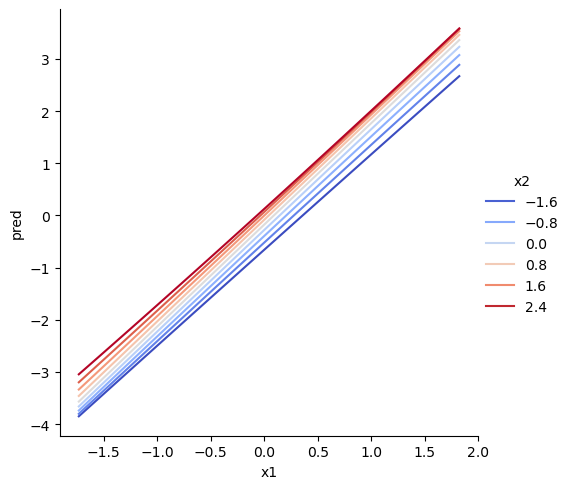

In [49]:
sns.relplot( data = viz_grid,
            x='x1', y='pred', kind='line',
            hue='x2', palette='coolwarm',
            estimator=None, units='x2')
plt.show()